# Lab 5 - Transfer Learning

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 🗓️ **Saturday, April 25th (23:59)**

---

##  Objectives

In this TP you will implement and compare **three transfer learning strategies** on a subset of the [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) using a pretrained **ResNet-18**:

| Strategy | What is trained? | Backbone frozen? |
|---|---|---|
| **A — Feature Extraction** | Head only | ✅ Fully frozen |
| **B — Fine-tune last block** | `layer4` + Head | ❄️ Partially frozen |
| **C — Full Fine-tuning** | Entire network | ❌ Not frozen |

You will **track all experiments live in TensorBoard** and produce a final side-by-side comparison.

---

>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.
> Questions marked 🧠 require a written answer in the markdown cell below.
>
> ⚠️ **First run:** The dataset download takes ~5 min. Start the download cell immediately.

---
## 0. Environment Setup

In [1]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import torch, torchvision
    print(f'✅ PyTorch {torch.__version__} / torchvision {torchvision.__version__}')
except ImportError:
    pip_install('torch torchvision')

try:
    from torch.utils.tensorboard import SummaryWriter
    print('✅ TensorBoard available')
except ImportError:
    pip_install('tensorboard')
    from torch.utils.tensorboard import SummaryWriter
    print('✅ TensorBoard installed')

✅ PyTorch 2.10.0+cu128 / torchvision 0.25.0+cu128
✅ TensorBoard available


In [3]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms, models

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cpu':
    print('   ⚠️  No GPU — training is slower but fully functional for this TP.')

NUM_WORKERS = 0

Device: cuda


---
## 1. Dataset — Oxford-IIIT Pets (5-breed subset)

`torchvision` handles the download automatically (~800 MB, first run only).

**Why a subset?** The full dataset has 37 breeds and ~7 000 images. To keep training under 5 min per run on CPU, we keep **5 breeds** and cap each at **80 train / 25 val images**.

**Important:** after subsetting, labels must be **re-mapped to 0–4** so the model head size matches.

In [4]:
# ── Hyper-parameters (feel free to tweak after you understand the lab) ─────────
DATA_DIR          = './data'
NUM_CLASSES       = 5 # OUT OF 37 CLASS
MAX_TRAIN_PER_CLS = 80
MAX_VAL_PER_CLS   = 25
BATCH_SIZE        = 32
NUM_EPOCHS        = 8

# ImageNet normalisation, required whenever using a pretrained backbone
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [5]:
# ── Transforms ────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Download (takes ~5 min on first run) ─────────────────────
print('⬇️  Downloading Oxford-IIIT Pets (skipped if already cached)...')
raw_train = datasets.OxfordIIITPet(DATA_DIR, split='trainval', download=True, transform=train_tf)
raw_val   = datasets.OxfordIIITPet(DATA_DIR, split='test',     download=True, transform=val_tf)
print(f'✅ Full dataset: {len(raw_train)} train / {len(raw_val)} test | {len(raw_train.classes)} breeds')

⬇️  Downloading Oxford-IIIT Pets (skipped if already cached)...


100%|██████████| 792M/792M [00:29<00:00, 26.6MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.8MB/s]


✅ Full dataset: 3680 train / 3669 test | 37 breeds


In [6]:
# ── Build the 5-breed subset with correct label remapping ─────────────────────

# Pick the first 5 breeds alphabetically
KEEP_CLASSES = sorted(raw_train.classes)[:NUM_CLASSES]
# Map original class names → new indices 0..4
OLD2NEW = {raw_train.class_to_idx[c]: new_idx
           for new_idx, c in enumerate(KEEP_CLASSES)}

print(f' Keeping: {KEEP_CLASSES}')
print(f'   Label remapping: {OLD2NEW}')


class RemappedSubset(torch.utils.data.Dataset):
    """
    Wraps a torchvision dataset:
      - Keeps only the chosen classes
      - Caps samples per class at `max_per_class`
      - Remaps labels to 0..N-1
    """
    def __init__(self, base_dataset, old2new, max_per_class):
        self.base = base_dataset
        self.old2new = old2new
        counts = {old: 0 for old in old2new}
        self.indices = []
        # OxfordIIITPet stores labels in ._labels (list of ints)
        for idx, lbl in enumerate(base_dataset._labels):
            if lbl in old2new and counts[lbl] < max_per_class:
                self.indices.append(idx)
                counts[lbl] += 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, old_label = self.base[self.indices[i]]
        return img, self.old2new[old_label]


train_dataset = RemappedSubset(raw_train, OLD2NEW, MAX_TRAIN_PER_CLS)
val_dataset   = RemappedSubset(raw_val,   OLD2NEW, MAX_VAL_PER_CLS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))

print(f'\n📦 Subset ready: {len(train_dataset)} train / {len(val_dataset)} val')
print(f'   Batches per epoch: {len(train_loader)} train / {len(val_loader)} val')

 Keeping: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']
   Label remapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}

📦 Subset ready: 400 train / 125 val
   Batches per epoch: 13 train / 4 val


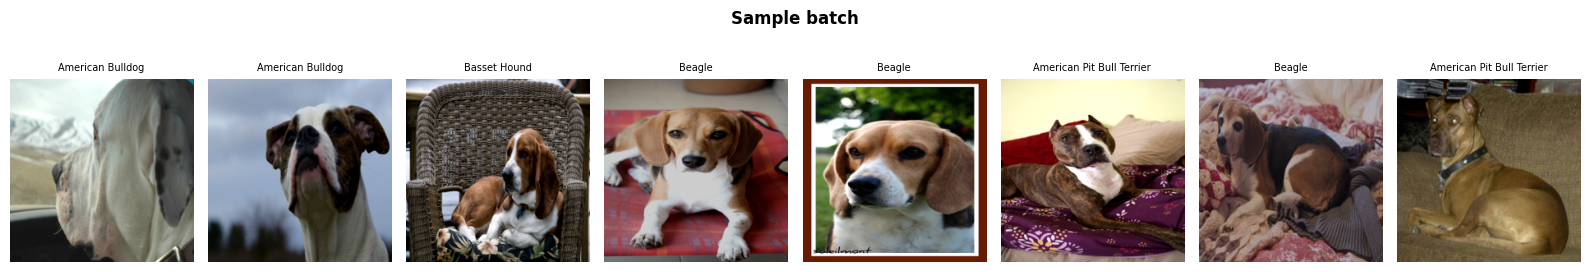

Label range in this batch: 0 → 4 ✅


In [7]:
# ── Visual sanity check ───────────────────────────────────────────────────────
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(1, min(8, BATCH_SIZE), figsize=(16, 3))
for i, ax in enumerate(axes):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(KEEP_CLASSES[lbls[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample batch', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Label range in this batch: {lbls.min().item()} → {lbls.max().item()} ✅')

---
## 2. Model Factory — your main coding task

All three strategies start from the **same ResNet-18 pretrained on ImageNet**.
The only difference is which layers have `requires_grad = True`.

### ResNet-18 structure (reminder from lecture)

```
ResNet-18
├── conv1 + bn1 + relu + maxpool   ← very early, always frozen in A & B
├── layer1                          ← early
├── layer2                          ← middle
├── layer3                          ← middle
├── layer4                          ← last conv block  ← unfreeze in B
├── avgpool
└── fc  : Linear(512, 1000)         ← REPLACE with Linear(512, NUM_CLASSES)
```

### Your task
Complete the three `### TODO` blocks in `build_model()` below.

In [9]:
def build_model(strategy: str) -> nn.Module:
    """
    Returns a ResNet-18 configured for `strategy`:
        'A'  Feature Extraction  — backbone fully frozen, head trained
        'B'  Fine-tune layer4    — layer4 + head trained, rest frozen
        'C'  Full Fine-tuning    — entire network trained
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # ------------------------------------------------------------------
    # Step 1 — Freeze / unfreeze backbone parameters
    # ------------------------------------------------------------------
    if strategy == 'A':
        # Freeze the entire backbone (all layers)
        for param in model.parameters():
            ###  TODO: If we want to freeze the backbone, should gradients be computed for these parameters?
            ### No, gradients should not be computed for frozen parameters, so we set requires_grad=False
            param.requires_grad = False   # ← replace ...

    elif strategy == 'B':
        # First freeze everything ...
        for param in model.parameters():
            param.requires_grad = False   # ← replace ...
        # ... then selectively unfreeze layer4
        # (Try unfreezing a different layer instead, e.g. layer3 or layer2 —
        # how does it affect performance and training time?)
        # the training time will be longer if we unfreeze more layers, but the performance may improve as well, especially if the new dataset is very different from ImageNet. Unfreezing layer4 allows the model to adapt its high-level features to the new task, while keeping the low-level features frozen. Unfreezing layer3 or layer2 would allow more adaptation but also increase training time and risk of overfitting.

        ### TODO: unfreeze model.layer4
        for param in model.layer4.parameters():
            param.requires_grad = True   # ← replace ...

    elif strategy == 'C':
        # Unfreeze the full network (this is the default, but be explicit)
        ### TODO: make every parameter trainable
        for param in model.parameters():
            param.requires_grad = True   # ← replace ...

    else:
        raise ValueError(f'Unknown strategy: {strategy!r}')

    # ------------------------------------------------------------------
    # Step 2 — Replace the classification head
    # The original fc is  Linear(512, 1000)  (1000 ImageNet classes)
    # We need              ## To be completed
    # ------------------------------------------------------------------
    in_features = model.fc.in_features          # ← replace ...
    ### TODO: replace model.fc with a new Linear layer
    model.fc = nn.Linear(in_features, NUM_CLASSES)                               # ← replace ...
    # The new head is always trainable — PyTorch initialises it randomly,
    # so requires_grad=True by default.

    return model


# ── Helper ────────────────────────────────────────────────────────────────────
def param_summary(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# ── Sanity check — run this after completing the TODOs ────────────────────────
print(f'{"Strategy":<6} {"Trainable":>12} {"Total":>12} {"% trained":>10}')
print('-' * 44)
for s in ['A', 'B', 'C']:
    m = build_model(s)
    total, trainable = param_summary(m)
    print(f'  {s}    {trainable:>12,} {total:>12,} {100*trainable/total:>9.1f}%')
    # Quick check: output layer must have NUM_CLASSES outputs
    assert m.fc.out_features == NUM_CLASSES, \
        f'Strategy {s}: fc.out_features={m.fc.out_features}, expected {NUM_CLASSES}'
print('\n✅ All strategies pass shape check')

Strategy    Trainable        Total  % trained
--------------------------------------------
  A           2,565   11,179,077       0.0%
  B       8,396,293   11,179,077      75.1%
  C      11,179,077   11,179,077     100.0%

✅ All strategies pass shape check


### 🧠 Question 1 — Parameter counts

Look at the trainable parameter counts printed above.

1. How many parameters does strategy A train? Why so few?
2. Strategy B trains more than A but less than C. Which layers account for the difference between A and B?
3. What is the risk of training strategy C on only 80 images per class?

**Your answer:**

1. 2,565 parameters. Only the head (the final fully connected layer) is trained, which has 512 input features and 5 output classes, resulting in 512*5 + 5 = 2,565 parameters.
2. 8,396,293, because in strategy B, the last convolutional block (layer4) is also trained, which has a significant number of parameters compared to the head alone.
3. 11,179,077, because training the entire network on a small dataset can lead to severe overfitting, where the model learns to memorize the training data rather than generalize to unseen data.

---
## 3. Training Engine

A single reusable function runs one full experiment and logs everything to TensorBoard.

**Differential learning rates:** the backbone and the head use different LRs.
- `lr_head` (e.g. `1e-3`) — the new head starts from random weights, needs a fast LR
- `lr_backbone` (e.g. `1e-4`) — the backbone has good pretrained weights, needs a slow LR to avoid catastrophic forgetting

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        ### TODO: reset gradients
        optimizer.zero_grad()

        ### TODO: forward pass
        out = model(imgs)

        ### TODO: compute loss
        loss = criterion(out, labels)

        ### TODO: backward pass
        loss.backward()

        ### TODO: update parameters
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item() * len(imgs)

        ### TODO: compute number of correct predictions
        correct += out.argmax(1).eq(labels).sum().item()

        n += len(imgs)

    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        ### TODO: forward pass (no gradients)
        out = model(imgs)

        ### TODO: compute loss
        loss = criterion(out, labels)

        total_loss += loss.item() * len(imgs)

        ### TODO: compute predictions
        correct += out.argmax(1).eq(labels).sum().item()

        n += len(imgs)

    return total_loss / n, correct / n

In [14]:
def run_experiment(
    strategy,
    train_loader,
    val_loader,
    num_epochs  = NUM_EPOCHS,
    lr_head     = 1e-3,
    lr_backbone = 1e-4,
    device      = DEVICE,
):
    sep = '=' * 60
    print(f'\n{sep}\n  Strategy {strategy}\n{sep}')

    model     = build_model(strategy).to(device)
    criterion = nn.CrossEntropyLoss()

    # -- Differential LR param groups ------------------------------------
    head_ids = {id(p) for p in model.fc.parameters()}
    backbone_params = [p for p in model.parameters()
                       if p.requires_grad and id(p) not in head_ids]
    head_params     = list(model.fc.parameters())

    param_groups = [{'params': head_params, 'lr': lr_head}]
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': lr_backbone})

    optimizer = optim.Adam(param_groups)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # -- TensorBoard writer ----------------------------------------------
    writer = SummaryWriter(log_dir=f'runs/strategy_{strategy}')

    history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        # TensorBoard
        writer.add_scalars('Loss',     {'train': tr_loss, 'val': va_loss}, epoch)
        writer.add_scalars('Accuracy', {'train': tr_acc,  'val': va_acc},  epoch)
        for i, pg in enumerate(optimizer.param_groups):
            tag = 'LR/head' if i == 0 else 'LR/backbone'
            writer.add_scalar(tag, pg['lr'], epoch)

        # History
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        best_val_acc = max(best_val_acc, va_acc)

        print(f'  Ep {epoch:02d}/{num_epochs}  '
              f'loss {tr_loss:.3f}/{va_loss:.3f}  '
              f'acc {100*tr_acc:.1f}%/{100*va_acc:.1f}%  '
              f'({time.time()-t0:.1f}s)')

    writer.close()
    history['best_val_acc'] = best_val_acc
    print(f'  ✅ Best val acc: {100*best_val_acc:.1f}%')
    return history


print('✅ Training engine ready.')

✅ Training engine ready.


---
## 4. Launch TensorBoard

Run the cell below **before** starting training so you can watch metrics update live.

In [15]:
import shutil, os
# Clear old runs so TensorBoard starts fresh
if os.path.exists('runs'):
    shutil.rmtree('runs')
    print('🗑️  Old TensorBoard logs cleared')

try:
    import google.colab
    get_ipython().run_line_magic('load_ext', 'tensorboard')
    get_ipython().run_line_magic('tensorboard', '--logdir runs')
except Exception:
    # Local
    print('💡 Open a terminal and run:')
    print('      tensorboard --logdir runs')
    print('   Then open:  http://localhost:6006')

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 12695), started 0:01:07 ago. (Use '!kill 12695' to kill it.)

<IPython.core.display.Javascript object>

---
## 5. Run the Three Experiments

> Run them one after the other. Watch TensorBoard update between runs.

**TensorBoard tip:** use the **"Runs" filter** on the left panel to overlay or isolate strategies.

### 5A — Feature Extraction
Only the new classification head is trained. Backbone weights are completely frozen.

In [16]:
history_A = run_experiment(
    strategy     = 'A',
    train_loader = train_loader,
    val_loader   = val_loader,
    lr_head      = 1e-3,
    # lr_backbone is irrelevant here (no backbone params are trainable)
)


  Strategy A
  Ep 01/8  loss 1.505/1.132  acc 35.2%/60.8%  (5.5s)
  Ep 02/8  loss 0.967/0.861  acc 67.8%/71.2%  (3.6s)
  Ep 03/8  loss 0.680/0.695  acc 85.2%/80.8%  (3.5s)
  Ep 04/8  loss 0.553/0.600  acc 86.5%/83.2%  (4.1s)
  Ep 05/8  loss 0.507/0.565  acc 88.5%/83.2%  (3.8s)
  Ep 06/8  loss 0.446/0.546  acc 90.5%/82.4%  (3.6s)
  Ep 07/8  loss 0.435/0.534  acc 91.5%/84.8%  (3.7s)
  Ep 08/8  loss 0.444/0.532  acc 91.8%/85.6%  (4.3s)
  ✅ Best val acc: 85.6%


### 5B — Fine-tune last block (`layer4` + head)
The last convolutional block is unfrozen and trained at a **10× smaller LR** than the head.

In [18]:
history_B = run_experiment(
    strategy     = 'B',
    train_loader = train_loader,
    val_loader   = val_loader,
    lr_head      = 1e-3,
    lr_backbone  = 1e-4,    # 10× smaller to protect pretrained features
)


  Strategy B
  Ep 01/8  loss 0.960/0.448  acc 66.0%/84.0%  (3.9s)
  Ep 02/8  loss 0.216/0.316  acc 95.2%/90.4%  (4.0s)
  Ep 03/8  loss 0.095/0.317  acc 98.5%/88.8%  (4.2s)
  Ep 04/8  loss 0.061/0.323  acc 99.5%/88.0%  (3.8s)
  Ep 05/8  loss 0.037/0.323  acc 99.5%/88.8%  (3.8s)
  Ep 06/8  loss 0.027/0.327  acc 100.0%/90.4%  (4.4s)
  Ep 07/8  loss 0.022/0.325  acc 100.0%/89.6%  (3.8s)
  Ep 08/8  loss 0.019/0.332  acc 100.0%/89.6%  (3.8s)
  ✅ Best val acc: 90.4%


### 5C — Full Fine-tuning
All layers are trainable. The backbone uses an **even smaller LR** to prevent catastrophic forgetting.

In [24]:
history_C = run_experiment(
    strategy     = 'C',
    train_loader = train_loader,
    val_loader   = val_loader,
    lr_head      = 1e-3,
    lr_backbone  = 1e-5,    # 100× smaller than head
)


  Strategy C
  Ep 01/8  loss 1.378/0.970  acc 46.5%/68.0%  (4.8s)
  Ep 02/8  loss 0.749/0.633  acc 81.5%/85.6%  (4.2s)
  Ep 03/8  loss 0.466/0.495  acc 92.5%/89.6%  (4.8s)
  Ep 04/8  loss 0.363/0.440  acc 94.5%/89.6%  (4.3s)
  Ep 05/8  loss 0.294/0.410  acc 94.8%/89.6%  (4.2s)
  Ep 06/8  loss 0.250/0.395  acc 97.2%/92.0%  (4.9s)
  Ep 07/8  loss 0.246/0.396  acc 94.2%/91.2%  (4.3s)
  Ep 08/8  loss 0.224/0.399  acc 97.5%/91.2%  (4.2s)
  ✅ Best val acc: 92.0%


---
## 6. Comparison

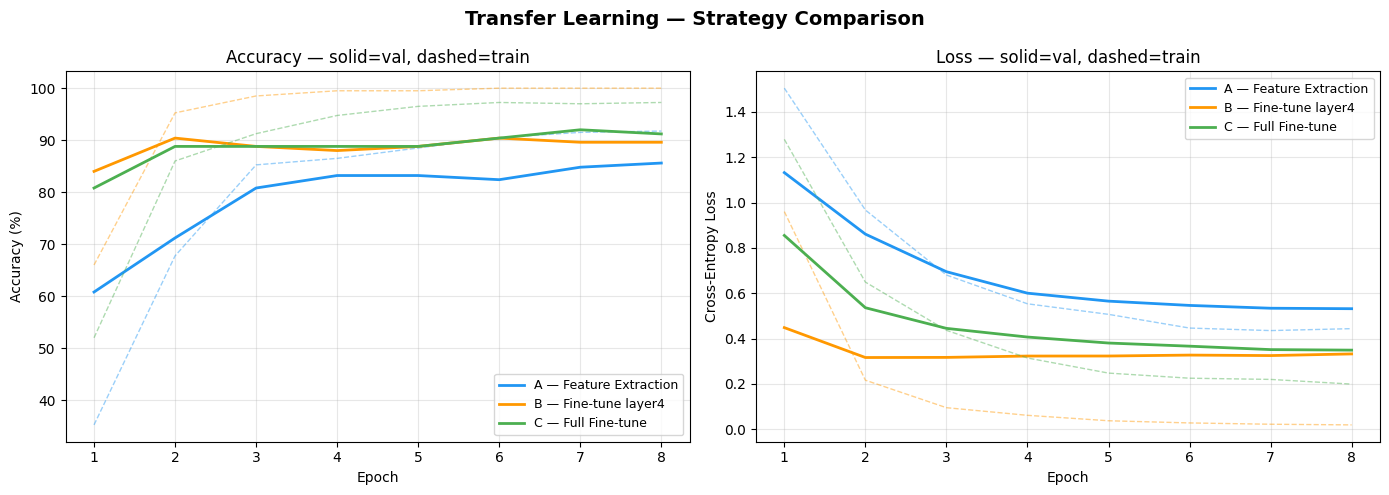

📊 Saved: comparison_curves.png


In [20]:
COLORS    = {'A': '#2196F3', 'B': '#FF9800', 'C': '#4CAF50'}
LABELS    = {'A': 'A — Feature Extraction', 'B': 'B — Fine-tune layer4', 'C': 'C — Full Fine-tune'}
histories = {'A': history_A, 'B': history_B, 'C': history_C}
epochs    = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transfer Learning — Strategy Comparison', fontsize=14, fontweight='bold')

for s, h in histories.items():
    c = COLORS[s]
    axes[0].plot(epochs, [v*100 for v in h['val_acc']],
                 color=c, lw=2, label=LABELS[s])
    axes[0].plot(epochs, [v*100 for v in h['train_acc']],
                 color=c, lw=1, ls='--', alpha=0.45)
    axes[1].plot(epochs, h['val_loss'],
                 color=c, lw=2, label=LABELS[s])
    axes[1].plot(epochs, h['train_loss'],
                 color=c, lw=1, ls='--', alpha=0.45)

for ax, title, ylab in zip(
    axes,
    ['Accuracy — solid=val, dashed=train', 'Loss — solid=val, dashed=train'],
    ['Accuracy (%)', 'Cross-Entropy Loss']
):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylab)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: comparison_curves.png')


────────────────────────────────────────────────────────────────────
Strategy                     Best Val Acc  Final Train Acc      Gap
────────────────────────────────────────────────────────────────────
  A — Feature Extraction            85.6%            91.8%    +6.2%
  B — Fine-tune layer4              90.4%           100.0%    +9.6%
  C — Full Fine-tune                92.0%            97.2%    +5.2%
────────────────────────────────────────────────────────────────────


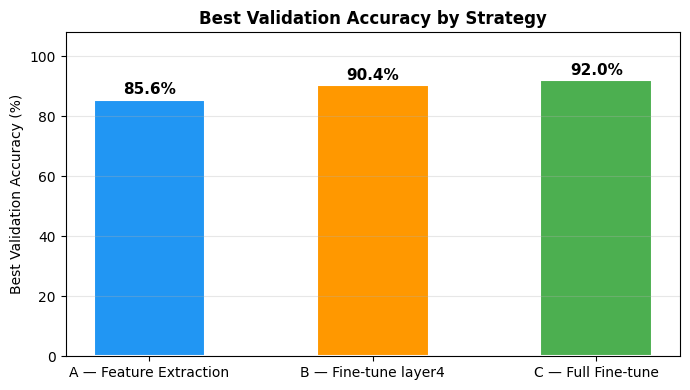

📊 Saved: comparison_bar.png


In [21]:
# ── Numeric summary table ─────────────────────────────────────────────────────
print('\n' + '─'*68)
print(f'{"Strategy":<28} {"Best Val Acc":>12} {"Final Train Acc":>16} {"Gap":>8}')
print('─'*68)
for s, h in histories.items():
    bv  = h['best_val_acc']
    ft  = h['train_acc'][-1]
    gap = ft - bv
    warn = '  ⚠️ overfit?' if gap > 0.15 else ''
    print(f'  {LABELS[s]:<26} {100*bv:>11.1f}%  {100*ft:>14.1f}%  {gap:>+7.1%}{warn}')
print('─'*68)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
names = [LABELS[s] for s in histories]
accs  = [100 * histories[s]['best_val_acc'] for s in histories]
bars  = ax.bar(names, accs, color=[COLORS[s] for s in histories],
               width=0.5, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('Best Validation Accuracy (%)')
ax.set_title('Best Validation Accuracy by Strategy', fontweight='bold')
ax.set_ylim(0, 108)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: comparison_bar.png')

---
## 7. 🧠 Reflection Questions

Answer in the markdown cell after each question. Use your TensorBoard curves and the comparison table.

### Question 2 — Convergence speed
Which strategy reaches its best validation accuracy earliest (fewest epochs)?  
Explain intuitively *why* freezing the backbone makes the head converge faster at the start.

**Your answer:**  
The strategy that reaches its best validation accuracy the earliest is B (fine-tuning of layer4), as early as epoch 2 (val_acc = 90.4%, then again at epoch 6).

Intuition: when (all or a large part of) the backbone is frozen, optimization is easier because there are far fewer parameters to adjust, and the extracted features remain stable. The head therefore learns faster at the beginning (an “easier” classification problem on already good representations).
However, a backbone that is too frozen can limit final performance (like A, which converges to a lower level).

### Question 3 — Overfitting
Look at the gap between train accuracy and val accuracy for strategy C.  
- Is overfitting visible? At which epoch does it start?
- Name **two** techniques that would reduce it without changing the strategy.

**Your answer:** 
- Yes, overrfitting starts between epochs 3 and 4.
- model regularization by doing dropout or data augmentation.

### Question 4 — Differential learning rates
In `run_experiment`, `lr_backbone` is set much smaller than `lr_head`.
- Why do pretrained backbone layers need a smaller LR?
- What is **catastrophic forgetting** and how does a small `lr_backbone` prevent it?

**Your answer:** 
- To avoiid catastrophic forgetting.
- Catastrophic forgetting is when a model forgets previously learned information upon learning new information. A small `lr_backbone` prevents it by allowing the model to make only small updates to the pretrained weights, thus preserving the useful features learned from the original task while still adapting to the new task.

### Question 5 — Strategy choice in the real world
You are a data scientist at a hospital. You have **200 labelled chest X-ray images** (pneumonia vs normal) and a ResNet-50 pretrained on ImageNet.

1. Which strategy (A, B, or C) would you pick? Justify with the 2×2 matrix from the lecture.
2. X-rays look very different from ImageNet photos. Does this affect your choice? How?

**Your answer:**
1. With 200 data points and a big differance between the source and target domains, we are in the case "Hardest Case", I would pick strategy B (fine-tuning of the last block) as a good compromise. Strategy A might not adapt enough to the new domain, while strategy C risks severe overfitting due to the small dataset size. Strategy B allows some adaptation to the new domain while keeping most of the pretrained features intact, which is beneficial when the new data is limited and different from ImageNet.
2. Yes, the large difference between X-rays and ImageNet photos makes it more likely that the pretrained features will not be perfectly suited to the new task. This increases the need for some fine-tuning (like in strategy B) to adapt the model to the new domain, while still leveraging the general features learned from ImageNet. Strategy A might not provide enough flexibility to adapt to the new domain, while strategy C could lead to overfitting given the small dataset size.

---
## 8.  Extra — If You Finish Early

### Catastrophic forgetting  *(~10 min)*
Re-run strategy C with `lr_backbone = 1e-3` (same as the head) instead of `1e-5`.  
What happens to val accuracy? Does it match the theoretical prediction?


In [23]:
history_C_CF = run_experiment(
    strategy     = 'C',
    train_loader = train_loader,
    val_loader   = val_loader,
    lr_head      = 1e-3,
    lr_backbone  = 1e-3,    # same as head
)


  Strategy C
  Ep 01/8  loss 0.753/6.367  acc 70.8%/24.8%  (4.2s)
  Ep 02/8  loss 0.564/3.154  acc 82.5%/54.4%  (4.2s)
  Ep 03/8  loss 0.273/1.115  acc 92.0%/62.4%  (4.9s)
  Ep 04/8  loss 0.200/1.557  acc 92.8%/53.6%  (4.2s)
  Ep 05/8  loss 0.138/0.910  acc 95.2%/69.6%  (4.2s)
  Ep 06/8  loss 0.056/0.588  acc 98.2%/83.2%  (4.9s)
  Ep 07/8  loss 0.027/0.539  acc 99.2%/82.4%  (4.2s)
  Ep 08/8  loss 0.022/0.518  acc 100.0%/82.4%  (4.4s)
  ✅ Best val acc: 83.2%


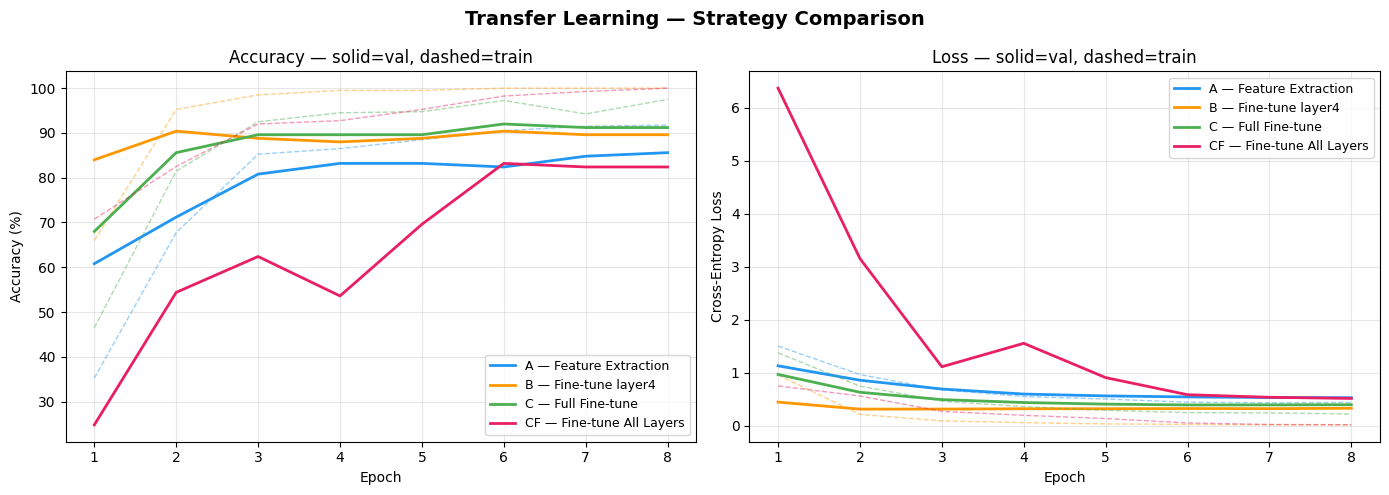

📊 Saved: comparison_curves.png


In [25]:
COLORS    = {'A': '#2196F3', 'B': '#FF9800', 'C': '#4CAF50', "CF": '#E91E63'}
LABELS    = {'A': 'A — Feature Extraction', 'B': 'B — Fine-tune layer4', 'C': 'C — Full Fine-tune', 'CF': 'CF — Fine-tune All Layers'}
histories = {'A': history_A, 'B': history_B, 'C': history_C, 'CF': history_C_CF}
epochs    = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transfer Learning — Strategy Comparison', fontsize=14, fontweight='bold')

for s, h in histories.items():
    c = COLORS[s]
    axes[0].plot(epochs, [v*100 for v in h['val_acc']],
                 color=c, lw=2, label=LABELS[s])
    axes[0].plot(epochs, [v*100 for v in h['train_acc']],
                 color=c, lw=1, ls='--', alpha=0.45)
    axes[1].plot(epochs, h['val_loss'],
                 color=c, lw=2, label=LABELS[s])
    axes[1].plot(epochs, h['train_loss'],
                 color=c, lw=1, ls='--', alpha=0.45)

for ax, title, ylab in zip(
    axes,
    ['Accuracy — solid=val, dashed=train', 'Loss — solid=val, dashed=train'],
    ['Accuracy (%)', 'Cross-Entropy Loss']
):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylab)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: comparison_curves.png')

Val accuracy drops significantly, confirming the theoretical prediction that a large learning rate for the backbone can lead to catastrophic forgetting, where the model quickly loses the useful features learned from ImageNet and fails to adapt effectively to the new task.